In [1]:
# Importo la libreria pandas, che userò per lavorare con i dati
import pandas as pd

# Carico il file CSV del dataset dentro un DataFrame chiamato df
df = pd.read_csv("train.csv")

# Mostro le prime 5 righe del dataset per vedere come sono fatti i dati
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
# Mostra informazioni generali sul dataset
# (numero righe, colonne, tipi di dati e valori nulli)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
# Mostra statistiche descrittive delle colonne numeriche
# (media, minimo, massimo, deviazione standard, ecc.)
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
# Controllo valori null nel dataset
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
# Rimuovo la colonna Postal Code perché non rilevante per l'analisi
df = df.drop(columns=["Postal Code"])

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Controllo i tipi di dati delle colonne
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [12]:
# Converto le colonne data specificando formato europeo (giorno/mese/anno)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [13]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [14]:
# Estraggo l'anno dalla data ordine
df["Order Year"] = df["Order Date"].dt.year

# Estraggo il mese dalla data ordine
df["Order Month"] = df["Order Date"].dt.month

In [17]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10


In [18]:
# Analisi vendite per categoria e anno
df_category_year_sales = df.groupby(["Category", "Order Year"])["Sales"].sum().reset_index()

# Mostro risultato
df_category_year_sales

,Category,Order Year,Sales
0,Furniture,2015,156477.8811
1,Furniture,2016,164053.8674
2,Furniture,2017,195813.0400
3,Furniture,2018,212313.7872
4,Office Supplies,2015,149512.8200
5,Office Supplies,2016,133124.4070
6,Office Supplies,2017,182417.5660
7,Office Supplies,2018,240367.5410
8,Technology,2015,173865.5070
9,Technology,2016,162257.7310


In [19]:
# Analisi vendite per sub-category e anno
df_subcat_year_sales = df.groupby(["Sub-Category", "Order Year"])["Sales"].sum().reset_index()

# Mostro risultato
df_subcat_year_sales

,Sub-Category,Order Year,Sales
0,Accessories,2015,23766.3960
1,Accessories,2016,40443.9700
2,Accessories,2017,41735.3640
3,Accessories,2018,58240.9700
4,Appliances,2015,15160.7150
...,...,...,...
63,Supplies,2018,15952.1100
64,Tables,2015,45757.7775
65,Tables,2016,35397.1955
66,Tables,2017,60762.1125


In [20]:
# Aggregazione per Category + Sub-Category + Year
df_hierarchy = df.groupby(
    ["Category", "Sub-Category", "Order Year"]
)["Sales"].sum().reset_index()

# Mostro il risultato
df_hierarchy.head()

,Category,Sub-Category,Order Year,Sales
0,Furniture,Bookcases,2015,20036.6776
1,Furniture,Bookcases,2016,37476.7749
2,Furniture,Bookcases,2017,26275.4665
3,Furniture,Bookcases,2018,30024.2797
4,Furniture,Chairs,2015,77046.4400


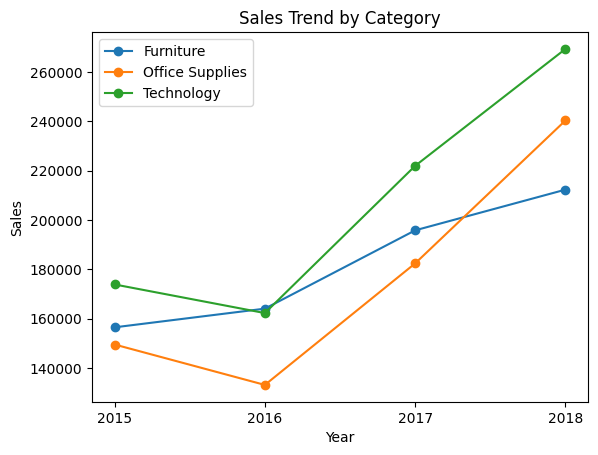

In [22]:
import matplotlib.pyplot as plt

# Line chart delle vendite totali per anno e categoria
for cat in df_hierarchy["Category"].unique():
    temp = df_hierarchy[df_hierarchy["Category"] == cat]
    yearly = temp.groupby("Order Year")["Sales"].sum()
dd
    plt.plot(yearly.index, yearly.values, marker="o", label=cat)

plt.title("Sales Trend by Category")
plt.xlabel("Year")
plt.ylabel("Sales")
# FIX asse X
plt.xticks(df_hierarchy["Order Year"].unique())
plt.legend()
plt.show()

In [23]:
import seaborn as sns

In [24]:
# filtro top dati (per non affollare il grafico)
top_subcat = df_hierarchy.groupby("Sub-Category")["Sales"].sum().nlargest(10).index
df_plot = df_hierarchy[df_hierarchy["Sub-Category"].isin(top_subcat)]

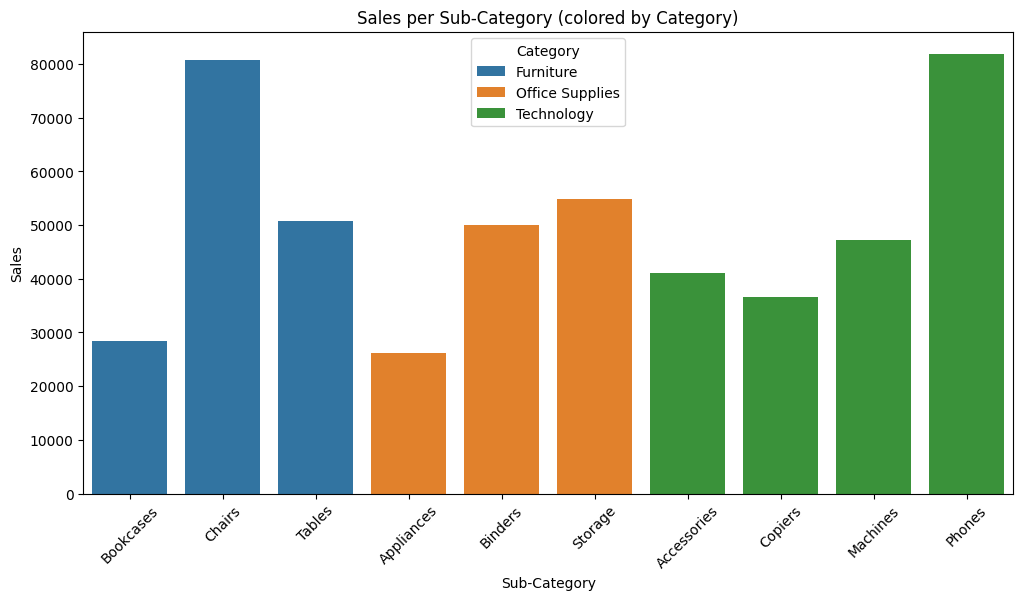

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_plot,
    x="Sub-Category",
    y="Sales",
    hue="Category",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Sales per Sub-Category (colored by Category)")
plt.show()

In [28]:
df_hierarchy

,Category,Sub-Category,Order Year,Sales
0,Furniture,Bookcases,2015,20036.6776
1,Furniture,Bookcases,2016,37476.7749
2,Furniture,Bookcases,2017,26275.4665
3,Furniture,Bookcases,2018,30024.2797
4,Furniture,Chairs,2015,77046.4400
...,...,...,...,...
63,Technology,Machines,2018,43544.6750
64,Technology,Phones,2015,77225.9560
65,Technology,Phones,2016,67870.6140
66,Technology,Phones,2017,78000.2200


In [29]:
df_hierarchy.to_excel("sales_analysis.xlsx", index=False)